In [1]:
import os
import re
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import L2
import cv2

In [2]:
# --- Chemins vers les données ---
res_folder = "./Datasets/DiaretDB0/resources/example_evalresults"
image_folder = "./Datasets/DiaretDB0/resources/images/diaretdb0_fundus_images"

# --- Configurations ---
TARGET_DISEASE_TAG = "hemorrhages"
IMAGE_EXTENSIONS = '.png'
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 13


# --- Fonctions d'extraction ---

def extract_file_number(filename):
    """Extrait le numéro de l'image (ex: 'image123.jpg' -> 123)."""
    match = re.search(r'image(\d+)', filename)
    return int(match.group(1)) if match else None

def create_dataset_from_images(image_folder_path, res_folder_path):
    """
    Parcourt les images existantes, trouve le label .res correspondant
    et crée un DataFrame pour la classification binaire.
    Label 1 = Hemorrhages (Non-Sain), Label 0 = Absence (Sain).
    """
    data = []

    # 1. Parcourir les images réelles
    for filename in os.listdir(image_folder_path):
        if not any(filename.lower().endswith(ext) for ext in IMAGE_EXTENSIONS):
            continue

        image_number = extract_file_number(filename)
        if image_number is None: continue

        res_filename = f"image{image_number}.res"
        res_path = os.path.join(res_folder_path, res_filename)

        label = 0  # Par défaut : Sain (0)

        # 2. Chercher le fichier .res et le label
        if os.path.exists(res_path):
            try:
                with open(res_path, "r") as f:
                    content = f.read().lower()
                    if TARGET_DISEASE_TAG in content:
                        label = 1
            except Exception as e:
                continue

        # 3. Ajouter l'entrée au jeu de données
        data.append({
            'filename': filename,
            'label': label,
            'image_path': os.path.join(image_folder_path, filename)
        })

    # Garantir que le DataFrame a les bonnes colonnes même s'il est vide
    if not data:
        print("Erreur: Aucun fichier image n'a pu être associé. Vérifiez les chemins et les noms.")
        return pd.DataFrame(columns=['filename', 'label', 'image_path'])

    return pd.DataFrame(data)

# Générer le DataFrame complet
df_data = create_dataset_from_images(image_folder, res_folder)

print(f"Nombre total d'images trouvées et labellisées : {len(df_data)}.")
if len(df_data) > 0:
    print("\n Distribution des classes (0=Sans hémorragie, 1=Hémorragie) :")
    print(df_data['label'].value_counts())

Nombre total d'images trouvées et labellisées : 130.

 Distribution des classes (0=Sans hémorragie, 1=Hémorragie) :
label
0    101
1     29
Name: count, dtype: int64


In [3]:
if len(df_data) > 0 and df_data['label'].nunique() > 1 and all(df_data['label'].value_counts() > 1):

    # 1. Séparation Train (60%) / Temp (40%)
    df_train, df_temp = train_test_split(
        df_data,
        test_size=0.4,
        random_state=42,
        stratify=df_data['label']
    )

    # 2. Séparation Validation (20%) / Test (20%)
    df_validation, df_test = train_test_split(
        df_temp,
        test_size=0.5,
        random_state=42,
        stratify=df_temp['label']
    )

    print("\n Séparation stratifiée réussie :")
    print(f"  - Entraînement (Train):    {len(df_train)} images")
    print(f"  - Validation (Validation): {len(df_validation)} images")
    print(f"  - Test (Test):            {len(df_test)} images")

else:
    print("\n Erreur: La stratification est impossible (données insuffisantes ou déséquilibre extrême).")


 Séparation stratifiée réussie :
  - Entraînement (Train):    78 images
  - Validation (Validation): 26 images
  - Test (Test):            26 images


In [4]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Nouvelle Fonction de pré-traitement pour rehausser les veines ---

def retina_boundary_and_rgb_clahe(img):
    """
    Applique le pipeline de pré-traitement :
    1. Extraction de la rétine (Boundary Detection).
    2. Amélioration du contraste des veines (CLAHE sur la composante L de LAB).
    3. Conserve l'information de couleur (RGB).

    Args:
        img (np.ndarray): Image RGB au format float [0, 1] ou [0, 255].

    Returns:
        np.ndarray: Image pré-traitée, en couleur améliorée, au format float [0, 1].
    """

    # 1. Conversion de l'image Keras au format uint8 (0-255) requis par OpenCV
    if img.max() <= 1.0:
        img_uint8 = (img * 255).astype(np.uint8)
    else:
        img_uint8 = img.astype(np.uint8)

    # S'assurer que l'image est bien RGB
    if img_uint8.ndim == 2 or img_uint8.shape[2] == 4:
        pass

    # --- Étape 1 : Extraction de la Rétine (Boundary Detection) ---

    # Isoler le canal Vert pour un meilleur contraste
    green_channel = img_uint8[:, :, 1]

    # Appliquer un léger flou pour réduire le bruit ponctuel qui pourrait fausser le seuillage
    green_blurred = cv2.GaussianBlur(green_channel, (5, 5), 0)

    # Seuil pour identifier la zone lumineuse de la rétine (on peut ajuster le seuil si 20 est trop élevé par exemple)
    _, thresh = cv2.threshold(green_blurred, 5, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Créer un masque noir initial
    mask = np.zeros_like(green_channel)

    if contours:
        # Trouver le plus grand contour (la rétine)
        largest_contour = max(contours, key=cv2.contourArea)
        # S'assurer que le contour est assez grand (pour éviter le bruit)
        if cv2.contourArea(largest_contour) > 100:
             cv2.drawContours(mask, [largest_contour], 0, 255, cv2.FILLED)
        else:
             # si le contour trouvé est du bruit alors remplir tout le masque avec du blanc
             mask[:] = 255
    else:
        # si le contour trouvé est du bruit alors remplir tout le masque avec du blanc
        mask[:] = 255

    # Appliquer le masque
    masked_img = cv2.bitwise_and(img_uint8, img_uint8, mask=mask)

    # --- Étape 2 : Amélioration du Contraste (CLAHE sur LAB) ---

    # Convertir l'image masquée de RGB à l'espace colorimétrique LAB
    # LAB sépare la Luminosité (L) de la couleur (A et B)
    lab = cv2.cvtColor(masked_img, cv2.COLOR_RGB2LAB)

    # Appliquer CLAHE uniquement sur le canal L (Luminosité)
    l_channel = lab[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=1, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l_channel)

    # Remplacer le canal L original par le canal L amélioré
    lab[:, :, 0] = l_enhanced

    # Reconvertir l'image de LAB à RGB
    final_img_rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # 3. Re-normaliser au format float [0, 1] pour Keras
    return final_img_rgb.astype(np.float32) / 255.0


# --- Définition des générateurs avec le nouveau pré-traitement ---

# Générateur pour Validation et Test)
datagen_basic = ImageDataGenerator(
    preprocessing_function=retina_boundary_and_rgb_clahe
)

# 1. Générateur d'ENTRAÎNEMENT
train_datagen = ImageDataGenerator(
    preprocessing_function=retina_boundary_and_rgb_clahe,

    # Augmentations Géométriques et Photométriques (Inchangées)
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, vertical_flip=True,
    zoom_range=[0.85, 1.15], shear_range=0.1, brightness_range=[1, 1.2], channel_shift_range=50.0,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_dataframe(
    df_train, x_col='filename', y_col='label', directory=image_folder,
    target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='raw'
)


# 2. Générateur de VALIDATION
validation_generator = datagen_basic.flow_from_dataframe(
    df_validation, x_col='filename', y_col='label', directory=image_folder,
    target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
)


# 3. Générateur de TEST
test_generator = datagen_basic.flow_from_dataframe(
    df_test, x_col='filename', y_col='label', directory=image_folder,
    target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='raw', shuffle=False
)

print("\n Générateurs redéfinis avec l'extraction de la rétine et CLAHE sur le canal de luminosité (LAB).")

Found 78 validated image filenames.
Found 26 validated image filenames.
Found 26 validated image filenames.

 Générateurs redéfinis avec l'extraction de la rétine et CLAHE sur le canal de luminosité (LAB).


Visualisation de 18 images (avec Augmentation) :


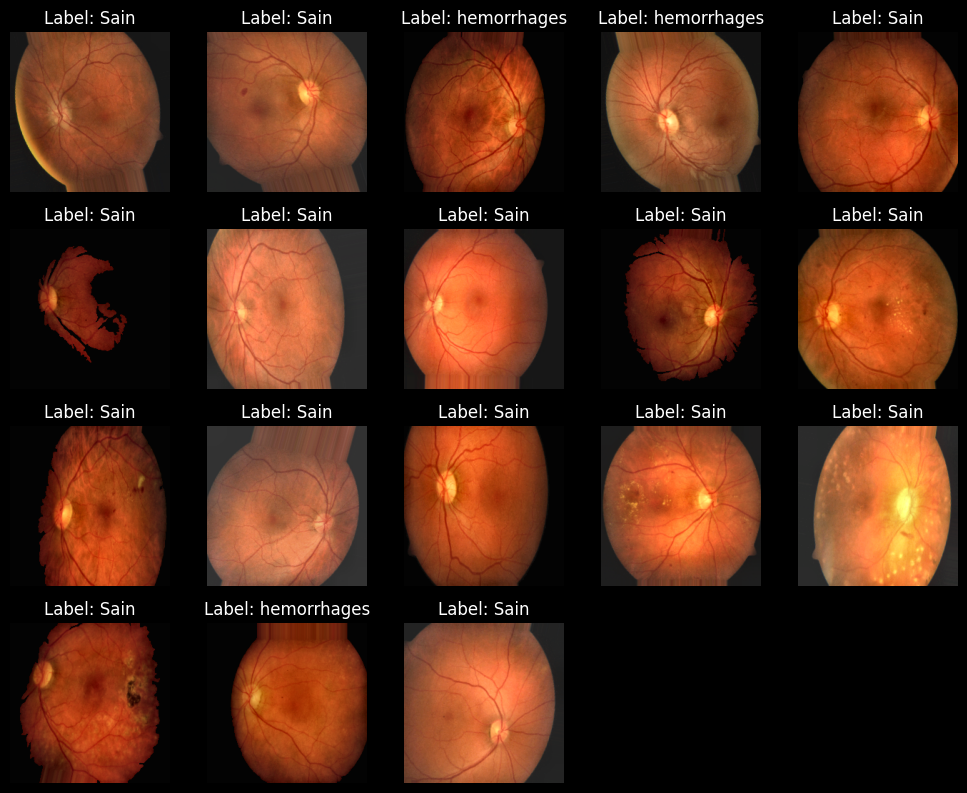

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_training_batch(generator, class_names, num_images=9):
    """
    Extrait un lot d'images du générateur et les affiche.

    Args:
        generator: L'objet Keras flow_from_dataframe (train_generator).
        class_names (dict): Dictionnaire pour mapper les labels numériques aux noms (ex: {0: 'Sain', 1: 'Haemorrhages'}).
        num_images (int): Nombre d'images à afficher.
    """

    # Extraire un lot (batch) de données
    # Le générateur retourne (images, labels)
    images, labels = next(generator)

    # S'assurer que les images sont au format 0-1 pour l'affichage Matplotlib
    # Elles sont normalement déjà au format 0-1 grâce au rescale=1./255
    if images.max() > 1.0:
        images = images / 255.0

    # Calculer la grille de visualisation
    rows = int(np.ceil(np.sqrt(num_images)))

    plt.figure(figsize=(10, 10))

    print(f"Visualisation de {num_images} images (avec Augmentation) :")

    for i in range(num_images):
        if i >= len(images):
            break

        plt.subplot(rows, rows, i + 1)

        # Afficher l'image (couleur)
        plt.imshow(images[i])

        # Récupérer l'étiquette (label) binaire
        label_index = int(labels[i])

        # Déterminer le nom de la classe
        title = f"Label: {class_names.get(label_index, 'Inconnu')}"

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- UTILISATION DE LA FONCTION ---

# 1. Définir le mapping des classes
# Basé sur notre labellisation : 0 = Sain, 1 = Hémorragies
CLASS_MAPPING = {
    0: 'Sain',
    1: TARGET_DISEASE_TAG
}

# 2. Exécuter la visualisation
visualize_training_batch(train_generator, CLASS_MAPPING, num_images=18)

In [6]:
# --- Définition de l'architecture du modèle ---

LR = 0.0001
from tensorflow.keras.regularizers import L2

model = Sequential([
    # Input image: 224x224x3
    # ----------------------------------------------------
    # 1)
    #    - Petites convolutions (3x3)
    #    - 8 filtres (motif simple)
    #    - Normalisation pour stabiliser l'apprentissage
    #    - MaxPooling pour réduire la résolution
    # ----------------------------------------------------
    Conv2D(8, (3, 3),
           strides=(1, 1),
           activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(epsilon=0.00001),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # ----------------------------------------------------
    # 2)
    #    - 16 filtres (motif complexe)
    #    - Normalisation pour stabiliser l'apprentissage
    #    - MaxPooling pour réduire la résolution
    # ----------------------------------------------------
    Conv2D(16, (3, 3), strides=(1, 1), activation='relu'),
    BatchNormalization(epsilon=0.00001),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),


    # --- Classification ---

    # 3) Passage aux couches pleinement connectées
    #    - Flatten
    # ----------------------------------------------------
    Flatten(),

    # ----------------------------------------------------
    # 4) Couche entièrement connectée (FC1)
    #    - 2 neurones comme dans le papier
    #    - ReLU pour capturer des relations non linéaires
    # ----------------------------------------------------
    Dense(2, activation='relu'),
    Dropout(0.3),                 # Dropout entre FC_1 et FC_2

    # ----------------------------------------------------
    # 5) Couche de sortie (FC2)
    #    - 1 neurone classification binaire
    #    - Sigmoid sortie entre 0 et 1 (sain ou hémorragies)
    # ----------------------------------------------------
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)


# --- Compilation du modèle ---
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy', # Obligatoire pour la classification binaire
    metrics=['accuracy']
)

print("Architecture du modèle CNN définie et compilée.")
model.summary()

# --- Section 5 : Entraînement du Modèle CNN ---

# Calcul des étapes par epoch
STEP_SIZE_TRAIN = train_generator.n // train_generator.batch_size
STEP_SIZE_VALID = validation_generator.n // validation_generator.batch_size

print(f"\n Démarrage de l'entraînement ")

history = model.fit(
    train_generator,
    steps_per_epoch=STEP_SIZE_TRAIN,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=STEP_SIZE_VALID,


)

print("\n Entraînement terminé avec équilibrage des classes !")

Architecture du modèle CNN définie et compilée.


/Users/camilleb/Desktop/ING3/MLOps/CNN-retinopathy/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        93,314 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,805 (370.33 KB)

 Trainable params: 94,757 (370.14 KB)

 Non-trainable params: 48 (192.00 B)


 Démarrage de l'entraînement 
Epoch 1/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3913 - loss: 0.9884 - val_accuracy: 0.4615 - val_loss: 0.6940
Epoch 2/13
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6250 - loss: 0.7328

/Users/camilleb/Desktop/ING3/MLOps/CNN-retinopathy/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step - accuracy: 0.6250 - loss: 0.7328 - val_accuracy: 0.6538 - val_loss: 0.6933
Epoch 3/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6957 - loss: 0.7342 - val_accuracy: 0.7692 - val_loss: 0.6930
Epoch 4/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 498ms/step - accuracy: 0.7500 - loss: 0.7239 - val_accuracy: 0.7692 - val_loss: 0.6930
Epoch 5/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 832ms/step - accuracy: 0.7609 - loss: 0.7120 - val_accuracy: 0.7692 - val_loss: 0.6929
Epoch 6/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step - accuracy: 0.7500 - loss: 0.7341 - val_accuracy: 0.7692 - val_loss: 0.6929
Epoch 7/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7969 - loss: 0.6916 - val_accuracy: 0.7692 - val_loss: 0.6929
Epoch 8/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 498ms/step - accuracy: 0.7857 - loss: 0.6928 - val_accuracy: 0.7692 - val_loss: 0.6928
Epoch 9/13
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8043 - loss: 0.6928 - val_accuracy: 0.8077 - val_loss: 0.6928
Epoch 10/13


In [7]:
# --- Évaluation sur l'ensemble de test ---
# Calcul du nombre d'étapes pour l'évaluation
STEP_SIZE_TEST = test_generator.n // test_generator.batch_size

loss, accuracy = model.evaluate(test_generator, steps=STEP_SIZE_TEST)

print(f"\nRésultats de l'évaluation sur l'ensemble de TEST ({test_generator.n} images) :")
print(f"  - Loss (Perte) : {loss:.4f}")
print(f"  - Accuracy (Précision) : {accuracy*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 0.3462 - loss: 0.6984

Résultats de l'évaluation sur l'ensemble de TEST (26 images) :
  - Loss (Perte) : 0.6984
  - Accuracy (Précision) : 34.62%


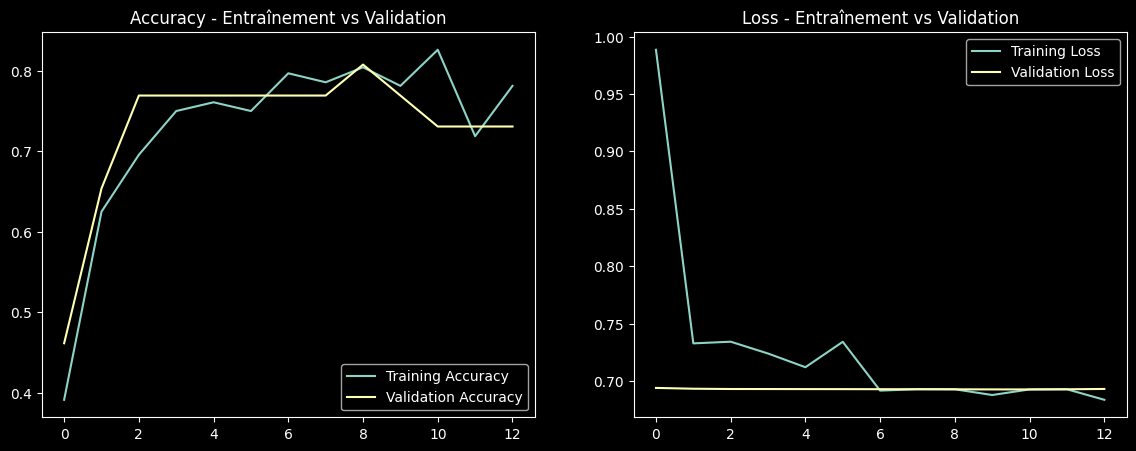

In [8]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    # Accuracy
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy - Entraînement vs Validation')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Loss - Entraînement vs Validation')
    plt.show()

plot_learning_curves(history)